 ### Understanding basic of kernels


 we will explore and compare why we need GPUS and what scale we need CPUS and breakdown on kernels optimization as well here

 this blogs is going to be fun how each matrix elements compute with CPU , GPU , GPU + kernels

 as we speak GPU process at parallely which is very fast and CPU does it in sequentially

 optimized kernel can improve latency on computing complex matrix multiplication here

 the takeaway of this blog would be to understand how the CPU and GPU paralleism works and how can we make the right decision choosing the hardaware


 for example for very tiny model like <1B you dont need GPU to run it until you serving real production usecases and your traffic grows 

In [3]:
import gc
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import triton
import triton.language as tl
import matplotlib.ticker as mticker

architecture_names = {
    (7, 5): "Turing",
    (8, 0): "Ampere (A100-class)",
    (8, 6): "Ampere (consumer-class)",
    (8, 9): "Ada Lovelace",
    (9, 0): "Hopper",
    (10, 0): "Blackwell",
    (12, 0): "Blackwell",
}

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not visible. In VS Code, choose the project's .venv Python kernel, "
        "then verify that `uv run python -c \"import torch; print(torch.cuda.is_available())\"` prints True."
    )

DEVICE_INDEX = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{DEVICE_INDEX}")
props = torch.cuda.get_device_properties(DEVICE_INDEX)
torch.manual_seed(0)

print(f"PyTorch:             {torch.__version__}")
print(f"PyTorch CUDA build:  {torch.version.cuda}")
print(f"Triton:              {triton.__version__}")
print(f"Device:              {props.name}")
print(f"Compute capability:  {props.major}.{props.minor} (sm_{props.major}{props.minor})")
print(f"CUDA architectures compiled into PyTorch: {torch.cuda.get_arch_list()}")

PyTorch:             2.12.1+cu130
PyTorch CUDA build:  13.0
Triton:              3.7.1
Device:              NVIDIA GeForce RTX 4050 Laptop GPU
Compute capability:  8.9 (sm_89)
CUDA architectures compiled into PyTorch: ['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


as you have noticed here that Floast operation has differnet in sizes the more accurate we need
the more memory we need to store on HBM, and matrix multiplication compute gets heavy you easiy get CUDA oom

In [4]:
MATRIX_ROWS = 2096
MATRIX_INNER = 2096
MATRIX_COLS = 2096
MATRIX_BLOCK_M = 64
MATRIX_BLOCK_N = 64
MATRIX_BLOCK_K = 32
MATRIX_NUM_WARPS = 4
INPUT_SCALE = 0.1
CPU_WARMUP_RUNS = 1
GPU_WARMUP_RUNS = 2

DTYPE_CONFIGS = [ 
    {"label": "FP16", "dtype": torch.float16, "bits": 16, "rtol": 2e-2, "atol": 2e-2},
    {"label": "FP32", "dtype": torch.float32, "bits": 32, "rtol": 1e-4, "atol": 1e-4},
]

CPU_PATH = "CPU PyTorch (resident)"
TORCH_GPU_PATH = "PyTorch GPU (resident)"
TRITON_GPU_PATH = "Triton GPU (resident)"
TRITON_ROUND_TRIP_PATH = "Triton GPU + round trip"
BENCHMARK_PATHS = [CPU_PATH, TORCH_GPU_PATH, TRITON_GPU_PATH, TRITON_ROUND_TRIP_PATH]
matmul_elements = MATRIX_ROWS * MATRIX_INNER * MATRIX_COLS
matmul_flops = 2 * matmul_elements
output_elements = MATRIX_ROWS * MATRIX_COLS

print("Expression: C = A @ B")
print(f"A shape:    [{MATRIX_ROWS:,}, {MATRIX_INNER:,}]")
print(f"B shape:    [{MATRIX_INNER:,}, {MATRIX_COLS:,}]")
print(f"C shape:    [{MATRIX_ROWS:,}, {MATRIX_COLS:,}]")

print(f"Output elements:       {output_elements:,}")
print(f"Multiply-accumulate terms: {matmul_elements:,}")
print(f"Estimated FLOPs:       {matmul_flops:,}  (~{matmul_flops / 1e9:.2f} GFLOPs)")
for config in DTYPE_CONFIGS:
    matrix_mib = MATRIX_ROWS * MATRIX_COLS * config["bits"] / 8 / 2**20
    print(f"One {config['label']:<10} output matrix: {matrix_mib:7.1f} MiB")
print(f"CPU worker threads available to PyTorch: {torch.get_num_threads()}")

Expression: C = A @ B
A shape:    [2,096, 2,096]
B shape:    [2,096, 2,096]
C shape:    [2,096, 2,096]
Output elements:       4,393,216
Multiply-accumulate terms: 9,208,180,736
Estimated FLOPs:       18,416,361,472  (~18.42 GFLOPs)
One FP16       output matrix:     8.4 MiB
One FP32       output matrix:    16.8 MiB
CPU worker threads available to PyTorch: 8


In [5]:
@triton.jit
def matrix_matmul_kernel(
    a,
    b,
    c,
    m,
    n,
    k,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_K: tl.constexpr,
):
    program_id = tl.program_id(axis=0)
    programs_n = tl.cdiv(n, BLOCK_N)
    program_m = program_id // programs_n
    program_n = program_id % programs_n

    offsets_m = program_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offsets_n = program_n * BLOCK_N + tl.arange(0, BLOCK_N)
    offsets_k = tl.arange(0, BLOCK_K)

    a_offsets = offsets_m[:, None] * k + offsets_k[None, :]
    b_offsets = offsets_k[:, None] * n + offsets_n[None, :]
    accumulator = tl.zeros((BLOCK_M, BLOCK_N), dtype=tl.float32)

    for _ in range(0, tl.cdiv(k, BLOCK_K)):
        a_values = tl.load(
            a + a_offsets,
            mask=(offsets_m[:, None] < m) & (offsets_k[None, :] < k),
            other=0.0,
        )
        b_values = tl.load(
            b + b_offsets,
            mask=(offsets_k[:, None] < k) & (offsets_n[None, :] < n),
            other=0.0,
        )
        accumulator += tl.dot(a_values, b_values, input_precision="ieee")
        a_offsets += BLOCK_K
        b_offsets += BLOCK_K * n
        offsets_k += BLOCK_K

    c_offsets = offsets_m[:, None] * n + offsets_n[None, :]
    c_mask = (offsets_m[:, None] < m) & (offsets_n[None, :] < n)
    tl.store(c + c_offsets, accumulator, mask=c_mask)


def launch_matrix_matmul(
    a,
    b,
    c,
    block_m=64,
    block_n=64,
    block_k=32,
    num_warps=4,
):
    if not (a.is_cuda and b.is_cuda and c.is_cuda):
        raise ValueError("The Triton path requires CUDA tensors.")
    if not (a.ndim == b.ndim == c.ndim == 2):
        raise ValueError("A, B, and C must be two-dimensional matrices.")
    if a.shape[1] != b.shape[0] or c.shape != (a.shape[0], b.shape[1]):
        raise ValueError("Expected A[M, K], B[K, N], and C[M, N].")
    if not (a.is_contiguous() and b.is_contiguous() and c.is_contiguous()):
        raise ValueError("This kernel expects contiguous row-major matrices.")

    m, k = a.shape
    _, n = b.shape
    grid = (triton.cdiv(m, block_m) * triton.cdiv(n, block_n),)
    matrix_matmul_kernel[grid](
        a,
        b,
        c,
        m,
        n,
        k,
        BLOCK_M=block_m,
        BLOCK_N=block_n,
        BLOCK_K=block_k,
        num_warps=num_warps,
    )

we will be performing simple add matrix here so we can see compare and see which does it fast and why we choose this architecture instead of this   


## LATENCY PLOTTING

In [6]:
def _wall_latency_ms(fn, warmup=3, repeats=10):
    for _ in range(warmup):
        fn()

    samples = []
    for _ in range(repeats):
        start = time.perf_counter()
        fn()
        samples.append((time.perf_counter() - start) * 1e3)

    return float(np.median(samples))


def _cuda_latency_ms(fn):
    return float(
        triton.testing.do_bench(
            fn,
            warmup=100,
            rep=500,
            return_mode="median",
        )
    )


def _empty_measurement(status, error=None):
    return {"latency_ms": np.nan, "status": status, "error": error}


def benchmark_matmul_dtype(
    source_a,
    source_b,
    dtype_config,
    *,
    block_m=MATRIX_BLOCK_M,
    block_n=MATRIX_BLOCK_N,
    block_k=MATRIX_BLOCK_K,
    num_warps=MATRIX_NUM_WARPS,
    cpu_warmup_runs=CPU_WARMUP_RUNS,
    gpu_warmup_runs=GPU_WARMUP_RUNS,
):
    """Benchmark one matmul dtype and return one row per execution path."""
    label = dtype_config["label"]
    dtype = dtype_config["dtype"]
    bits = dtype_config["bits"]
    m, k = source_a.shape
    _, n = source_b.shape
    output_numel = m * n
    output_mib = output_numel * bits / 8 / 2**20
    measurements = {}
    correctness = {
        "correct": False,
        "max_abs_error": np.nan,
        "mean_abs_error": np.nan,
        "peak_gpu_memory_mib": np.nan,
    }

    if dtype is None:
        message = f"{label} is not available in this PyTorch build"
        measurements = {
            path: _empty_measurement("unavailable", message)
            for path in BENCHMARK_PATHS
        }
    else:
        a_cpu = source_a.to(dtype)
        b_cpu = source_b.to(dtype)

        # CPU PyTorch matmul latency.
        c_cpu = None
        try:
            c_cpu = torch.empty((m, n), dtype=dtype)
            for _ in range(cpu_warmup_runs):
                torch.matmul(a_cpu, b_cpu, out=c_cpu)
            measurements[CPU_PATH] = {
                "latency_ms": _wall_latency_ms(
                    lambda: torch.matmul(a_cpu, b_cpu, out=c_cpu)
                ),
                "status": "ok",
                "error": None,
            }
        except Exception as exc:
            measurements[CPU_PATH] = _empty_measurement("unsupported", str(exc))
        finally:
            del c_cpu

        a_gpu = b_gpu = c_gpu = c_from_gpu = None
        try:
            torch.cuda.reset_peak_memory_stats(DEVICE)
            a_gpu = a_cpu.to(DEVICE)
            b_gpu = b_cpu.to(DEVICE)
            c_gpu = torch.empty((m, n), dtype=dtype, device=DEVICE)
            c_from_gpu = torch.empty((m, n), dtype=dtype)

            # PyTorch GPU matmul latency with resident tensors.
            try:
                for _ in range(gpu_warmup_runs):
                    torch.matmul(a_gpu, b_gpu, out=c_gpu)
                measurements[TORCH_GPU_PATH] = {
                    "latency_ms": _cuda_latency_ms(
                        lambda: torch.matmul(a_gpu, b_gpu, out=c_gpu)
                    ),
                    "status": "ok",
                    "error": None,
                }
            except Exception as exc:
                measurements[TORCH_GPU_PATH] = _empty_measurement(
                    "unsupported", str(exc)
                )

            # Triton GPU matmul latency with resident tensors.
            try:
                launch = lambda: launch_matrix_matmul(
                    a_gpu,
                    b_gpu,
                    c_gpu,
                    block_m,
                    block_n,
                    block_k,
                    num_warps,
                )
                launch()  # Compile the dtype specialization outside the timing.
                for _ in range(gpu_warmup_runs):
                    launch()
                measurements[TRITON_GPU_PATH] = {
                    "latency_ms": _cuda_latency_ms(launch),
                    "status": "ok",
                    "error": None,
                }

                # Full CPU → GPU → Triton matmul → CPU latency.
                def triton_round_trip():
                    a_gpu.copy_(a_cpu)
                    b_gpu.copy_(b_cpu)
                    launch()
                    c_from_gpu.copy_(c_gpu)
                    torch.cuda.synchronize()

                measurements[TRITON_ROUND_TRIP_PATH] = {
                    "latency_ms": _wall_latency_ms(triton_round_trip),
                    "status": "ok",
                    "error": None,
                }

                # Validate Triton against FP32 PyTorch matmul on the same quantized inputs.
                reference_gpu = torch.matmul(a_gpu.float(), b_gpu.float())
                storage_reference = reference_gpu.to(dtype).float()
                actual = c_gpu.float()
                error = (actual - storage_reference).abs()
                torch.testing.assert_close(
                    actual,
                    storage_reference,
                    rtol=dtype_config["rtol"],
                    atol=dtype_config["atol"],
                )
                correctness = {
                    "correct": True,
                    "max_abs_error": float(error.max()),
                    "mean_abs_error": float(error.mean()),
                    "peak_gpu_memory_mib": torch.cuda.max_memory_allocated(DEVICE) / 2**20,
                }
                del reference_gpu, storage_reference, actual, error
            except Exception as exc:
                measurements[TRITON_GPU_PATH] = _empty_measurement("failed", str(exc))
                measurements[TRITON_ROUND_TRIP_PATH] = _empty_measurement(
                    "failed", str(exc)
                )
        except Exception as exc:
            for path in (
                TORCH_GPU_PATH,
                TRITON_GPU_PATH,
                TRITON_ROUND_TRIP_PATH,
            ):
                measurements.setdefault(
                    path, _empty_measurement("failed", str(exc))
                )
        finally:
            del a_gpu, b_gpu, c_gpu, c_from_gpu
            del a_cpu, b_cpu
            gc.collect()
            torch.cuda.empty_cache()

    result_rows = []
    for path in BENCHMARK_PATHS:
        result_rows.append(
            {
                "dtype": label,
                "dtype_bits": bits,
                "path": path,
                "latency_ms": measurements[path]["latency_ms"],
                "status": measurements[path]["status"],
                "error": measurements[path]["error"],
                "rows": m,
                "inner_dim": k,
                "cols": n,
                "numel": output_numel,
                "block_m": block_m,
                "block_n": block_n,
                "block_k": block_k,
                "num_warps": num_warps,
                "matrix_mib": output_mib,
                **correctness,
            }
        )
    return result_rows


def run_matmul_benchmarks(
    rows=MATRIX_ROWS,
    inner_dim=MATRIX_INNER,
    cols=MATRIX_COLS,
    dtype_configs=DTYPE_CONFIGS,
    *,
    seed=0,
    input_scale=INPUT_SCALE,
    **benchmark_kwargs,
):
    """Run the same matrix multiplication for every configured dtype."""
    generator = torch.Generator(device="cpu").manual_seed(seed)
    source_a = torch.randn(
        (rows, inner_dim), dtype=torch.float32, generator=generator
    ).mul_(input_scale)
    source_b = torch.randn(
        (inner_dim, cols), dtype=torch.float32, generator=generator
    ).mul_(input_scale)

    result_rows = []
    try:
        for dtype_config in dtype_configs:
            print(f"Benchmarking matmul {dtype_config['label']} ...")
            result_rows.extend(
                benchmark_matmul_dtype(
                    source_a,
                    source_b,
                    dtype_config,
                    **benchmark_kwargs,
                )
            )
    finally:
        del source_a, source_b
        gc.collect()

    return pd.DataFrame(result_rows)

## FLOPS PLOTTING

In [7]:
import matplotlib.ticker as mticker

RESIDENT_PATHS = [
    CPU_PATH,
    TORCH_GPU_PATH,
    TRITON_GPU_PATH,
]

FLOPS_COLORS = {
    CPU_PATH: "#6B7280",
    TORCH_GPU_PATH: "#4C78A8",
    TRITON_GPU_PATH: "#F58518",
}


def plot_matmul_tflops(results, *, log_scale=True):
    """
    Plot achieved throughput for C[M,N] = A[M,K] @ B[K,N].

    FLOPs = 2*M*N*K
    TFLOP/s = FLOPs / elapsed_seconds / 1e12
             = FLOPs / (latency_ms * 1e9)
    """
    data = results.copy()

    valid = (
        data["path"].isin(RESIDENT_PATHS)
        & data["status"].str.lower().eq("ok")
        & data["latency_ms"].gt(0)
    )
    data = data.loc[valid].copy()

    data["flop_count"] = (
        2.0
        * data["rows"].astype(float)
        * data["inner_dim"].astype(float)
        * data["cols"].astype(float)
    )

    data["tflops"] = data["flop_count"] / (data["latency_ms"] * 1e9)

    dtype_order = [
        dtype
        for dtype in DTYPE_ORDER
        if dtype in set(data["dtype"].dropna())
    ]

    x = np.arange(len(dtype_order), dtype=np.float64)
    width = 0.22

    fig, ax = plt.subplots(figsize=(9, 6))

    plotted_values = []

    for index, path in enumerate(RESIDENT_PATHS):
        path_data = (
            data[data["path"].eq(path)]
            .drop_duplicates("dtype", keep="last")
            .set_index("dtype")
        )

        values = np.array(
            [
                path_data.loc[dtype, "tflops"]
                if dtype in path_data.index
                else np.nan
                for dtype in dtype_order
            ],
            dtype=np.float64,
        )

        mask = np.isfinite(values)

        if not mask.any():
            continue

        positions = x + (index - (len(RESIDENT_PATHS) - 1) / 2) * width

        bars = ax.bar(
            positions[mask],
            values[mask],
            width=width * 0.90,
            color=FLOPS_COLORS[path],
            label=PATH_LABELS[path],
            edgecolor="white",
            linewidth=0.8,
        )

        ax.bar_label(
            bars,
            labels=[f"{value:.2f}" for value in values[mask]],
            padding=3,
            rotation=90,
            fontsize=8,
        )

        plotted_values.extend(values[mask])

    if plotted_values:
        positive = np.asarray(plotted_values, dtype=np.float64)
        positive = positive[positive > 0]

        if positive.size:
            y_min = positive.min()
            y_max = positive.max()

            if log_scale:
                ax.set_yscale("log")
                ax.set_ylim(max(y_min * 0.5, 1e-4), y_max * 3.0)

                tick_candidates = np.array([
                    0.001, 0.01, 0.1, 1, 10, 100, 1000
                ])

                ticks = tick_candidates[
                    (tick_candidates >= y_min * 0.5)
                    & (tick_candidates <= y_max * 3.0)
                ]

                ax.set_yticks(ticks)

                ax.yaxis.set_major_formatter(
                    mticker.FuncFormatter(lambda y, _: f"{y:g}")
                )

                ax.yaxis.set_minor_formatter(mticker.NullFormatter())

            else:
                ax.set_ylim(0, y_max * 1.25)

    ax.set_title(
        "Matmul throughput comparison",
        fontsize=15,
        fontweight="bold",
        pad=22,
    )

    ax.text(
        0.5,
        1.015,
        "Higher is better ↑ | TFLOP/s = total FLOPs ÷ time",
        transform=ax.transAxes,
        ha="center",
        fontsize=9,
        color="#444444",
    )

    ax.set_ylabel("Achieved TFLOP/s", fontsize=11)
    ax.set_xlabel("Data type", fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(dtype_order, fontsize=10)

    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    ax.legend(
        title="Execution path",
        frameon=False,
        fontsize=9,
        title_fontsize=9,
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
    )

    plt.tight_layout(rect=(0.04, 0.14, 0.98, 0.92))

    columns = [
        "dtype",
        "path",
        "rows",
        "inner_dim",
        "cols",
        "latency_ms",
        "flop_count",
        "tflops",
    ]

    return data[columns], fig, ax

I benchmarked FP16 and FP32 Iskippewd Fp8 becuase its not supported by the torch version 2.12.1+cu130, so I go with this version for now, we ran thre different benchmark 

* CPU 
* Pytorch GPU baseline
* Trition baseline 
* round trips 

In [8]:
DTYPE_ORDER = ["FP8 (E4M3)", "FP16", "FP32"]

PLOT_PATHS = [
    CPU_PATH,
    TORCH_GPU_PATH,
    TRITON_GPU_PATH,
    TRITON_ROUND_TRIP_PATH,
]

PATH_LABELS = {
    CPU_PATH: "CPU PyTorch",
    TORCH_GPU_PATH: "PyTorch GPU",
    TRITON_GPU_PATH: "Triton GPU",
    TRITON_ROUND_TRIP_PATH: "Triton + transfers",
}

PATH_COLORS = {
    CPU_PATH: "#6B7280",
    TORCH_GPU_PATH: "#4C78A8",
    TRITON_GPU_PATH: "#F58518",
    TRITON_ROUND_TRIP_PATH: "#B279A2",
}


def plot_matmul_latency_comparison(results, *, log_scale=True):
    """Plot one large latency comparison without modifying results."""
    dtype_order = [
        dtype
        for dtype in DTYPE_ORDER
        if dtype in set(results["dtype"].dropna())
    ]
    x = np.arange(len(dtype_order), dtype=np.float64)
    fig, ax = plt.subplots(figsize=(9, 6))
    width = 0.60 / len(PLOT_PATHS) 
    plotted_latencies = []

    for path_index, path in enumerate(PLOT_PATHS):
        path_rows = (
            results.loc[results["path"].eq(path)]
            .drop_duplicates("dtype", keep="last")
            .set_index("dtype")
        )
        latencies = np.full(len(dtype_order), np.nan, dtype=np.float64)

        for dtype_index, dtype in enumerate(dtype_order):
            if dtype not in path_rows.index:
                continue
            row = path_rows.loc[dtype]
            latency = float(row["latency_ms"])
            if str(row["status"]).lower() == "ok" and np.isfinite(latency):
                latencies[dtype_index] = latency

        valid = np.isfinite(latencies)
        if not valid.any():
            continue

        positions = x + (path_index - (len(PLOT_PATHS) - 1) / 2) * width
        bars = ax.bar(
            positions[valid],
            latencies[valid],
            width=width * 0.92,
            color=PATH_COLORS[path],
            label=PATH_LABELS[path],
            edgecolor="white",
            linewidth=0.8,
        )
        ax.bar_label(
            bars,
            labels=[f"{latency:.3f} ms" for latency in latencies[valid]],
            padding=5,
            fontsize=10,
            rotation=90,
        )
        plotted_latencies.extend(latencies[valid])

    if log_scale:
        ax.set_yscale("log")

    if plotted_latencies:
        positive = np.asarray(plotted_latencies, dtype=np.float64)
        positive = positive[positive > 0]
        if positive.size:
            if log_scale:
                ax.set_ylim(positive.min() * 0.60, positive.max() * 3.0)
            else:
                ax.set_ylim(0, positive.max() * 1.28)

    ax.set_title(
        "Matmul latency comparison — lower is better ↓",
        fontsize=18,
        fontweight="bold",
        pad=34,
    )
    ax.text(
        0.5,
        1.015,
        "C = A @ B | latency in milliseconds",
        transform=ax.transAxes,
        ha="center",
        fontsize=11,
        color="#444444",
    )
    ax.set_ylabel("Latency (ms)", fontsize=13)
    ax.set_xlabel("Data type", fontsize=12)
    ax.set_xticks(x, dtype_order, fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(
        title="Execution path",
        frameon=False,
        fontsize=11,
        title_fontsize=11,
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.10),
    )

    if "props" in globals() and not results.empty:
        config = results.iloc[0]
        fig.text(
            0.5,
            0.018,
            (
                f"GPU: {props.name} | sm_{props.major}{props.minor} | "
                f"A: {int(config.rows):,} × {int(config.inner_dim):,} | "
                f"B: {int(config.inner_dim):,} × {int(config.cols):,} | "
                f"block: {int(config.block_m)} × {int(config.block_n)} × {int(config.block_k)} | "
                f"warps: {int(config.num_warps)}"
            ),
            ha="center",
            fontsize=9,
            color="#555555",
        )

    plt.tight_layout(rect=(0.03, 0.12, 0.99, 0.94))
    return fig, ax

initially I ran 1k matrix element multiplication to compare how GPU works parallely to beat CPU so that is main reason we have using GPU accelerated AI developements 

and also we will see 1k and 10K matrix pass 

## 1K matrix pass

Expression: C = A @ B
A shape:    [1,096, 1,096]
B shape:    [1,096, 1,096]
C shape:    [1,096, 1,096]
Output elements:       1,201,216
Multiply-accumulate terms: 1,316,532,736
Estimated FLOPs:       2,633,065,472  (~2.63 GFLOPs)
One FP16       output matrix:     2.3 MiB
One FP32       output matrix:     4.6 MiB

In [9]:
MATRIX_ROWS = 1096
MATRIX_INNER = 1096
MATRIX_COLS = 1096
benchmark_results = run_matmul_benchmarks(
    rows=MATRIX_ROWS, inner_dim=MATRIX_INNER, cols=MATRIX_COLS
)   

Benchmarking matmul FP16 ...
Benchmarking matmul FP32 ...


In [10]:
display(
    benchmark_results[
        ["dtype", "path", "latency_ms", "status"]
    ].round({"latency_ms": 3})
)

,dtype,path,latency_ms,status
0,FP16,CPU PyTorch (resident),927.953,ok
1,FP16,PyTorch GPU (resident),0.231,ok
2,FP16,Triton GPU (resident),0.234,ok
3,FP16,Triton GPU + round trip,1.233,ok
4,FP32,CPU PyTorch (resident),10.145,ok
5,FP32,PyTorch GPU (resident),0.607,ok
6,FP32,Triton GPU (resident),0.706,ok
7,FP32,Triton GPU + round trip,2.631,ok


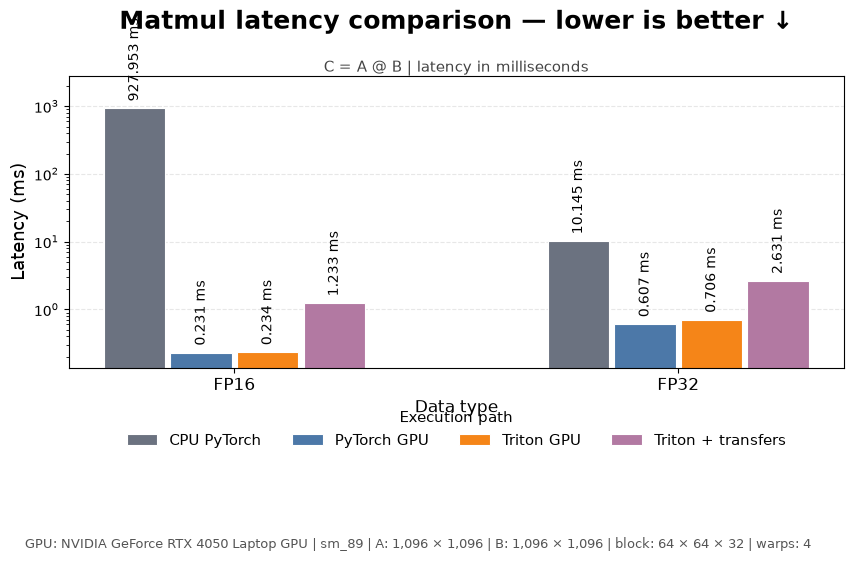

In [11]:
benchmark_figure, benchmark_axis = plot_matmul_latency_comparison(benchmark_results)
plt.show()

,dtype,path,rows,inner_dim,cols,latency_ms,flop_count,tflops
0,FP16,CPU PyTorch (resident),1096,1096,1096,927.9525,2.633065e+09,0.0028
1,FP16,PyTorch GPU (resident),1096,1096,1096,0.2314,2.633065e+09,11.3777
2,FP16,Triton GPU (resident),1096,1096,1096,0.2345,2.633065e+09,11.2286
4,FP32,CPU PyTorch (resident),1096,1096,1096,10.1449,2.633065e+09,0.2595
5,FP32,PyTorch GPU (resident),1096,1096,1096,0.6072,2.633065e+09,4.3362
6,FP32,Triton GPU (resident),1096,1096,1096,0.7055,2.633065e+09,3.7320


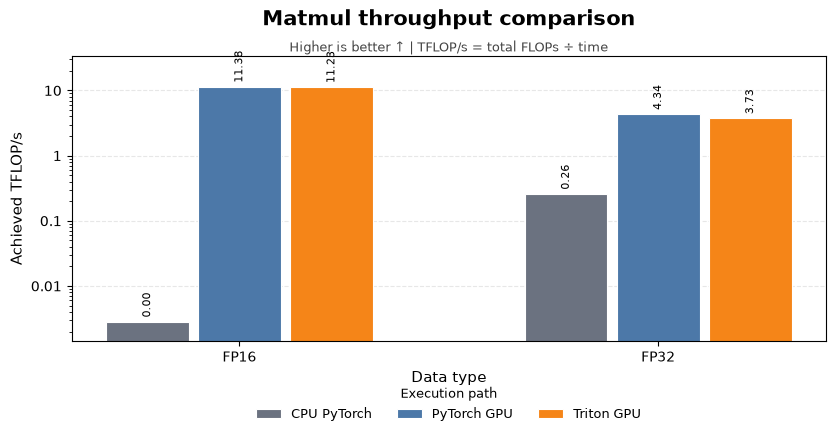

In [12]:
flops_results, fig, ax = plot_matmul_tflops(benchmark_results)
display(flops_results.round({"latency_ms": 4, "tflops": 4}))
plt.show()

## 2K matrix pass

Expression: C = A @ B
A shape:    [2,096, 2,096]
B shape:    [2,096, 2,096]
C shape:    [2,096, 2,096]
Output elements:       4,393,216
Multiply-accumulate terms: 9,208,180,736
Estimated FLOPs:       18,416,361,472  (~18.42 GFLOPs)
One FP16       output matrix:     8.4 MiB
One FP32       output matrix:    16.8 MiB 


In [13]:
MATRIX_ROWS = 2096
MATRIX_INNER = 2096
MATRIX_COLS = 2096
benchmark_results = run_matmul_benchmarks(
    rows=MATRIX_ROWS, inner_dim=MATRIX_INNER, cols=MATRIX_COLS
)   

Benchmarking matmul FP16 ...
Benchmarking matmul FP32 ...


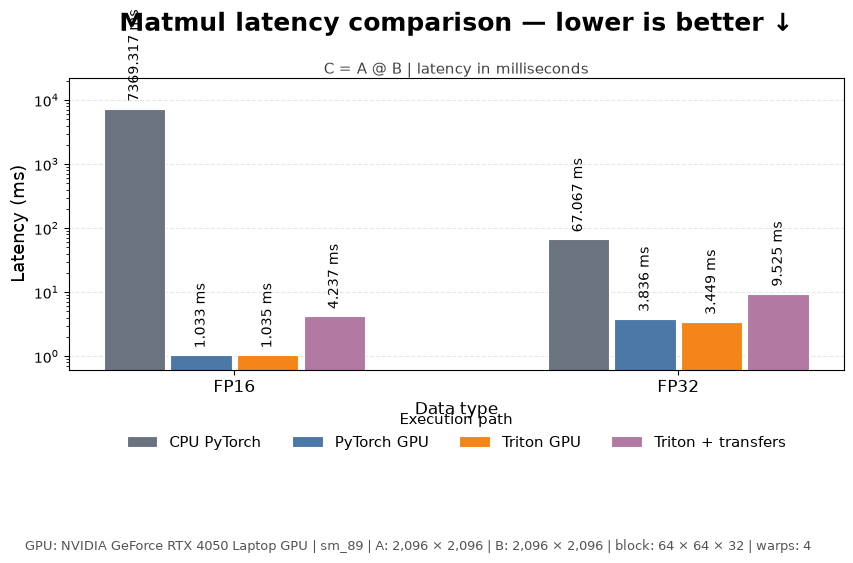

In [14]:
benchmark_figure, benchmark_axis = plot_matmul_latency_comparison(benchmark_results)
plt.show()

,dtype,path,rows,inner_dim,cols,latency_ms,flop_count,tflops
0,FP16,CPU PyTorch (resident),2096,2096,2096,7369.3171,1.841636e+10,0.0025
1,FP16,PyTorch GPU (resident),2096,2096,2096,1.0332,1.841636e+10,17.8243
2,FP16,Triton GPU (resident),2096,2096,2096,1.0353,1.841636e+10,17.7890
4,FP32,CPU PyTorch (resident),2096,2096,2096,67.0668,1.841636e+10,0.2746
5,FP32,PyTorch GPU (resident),2096,2096,2096,3.8364,1.841636e+10,4.8004
6,FP32,Triton GPU (resident),2096,2096,2096,3.4493,1.841636e+10,5.3392


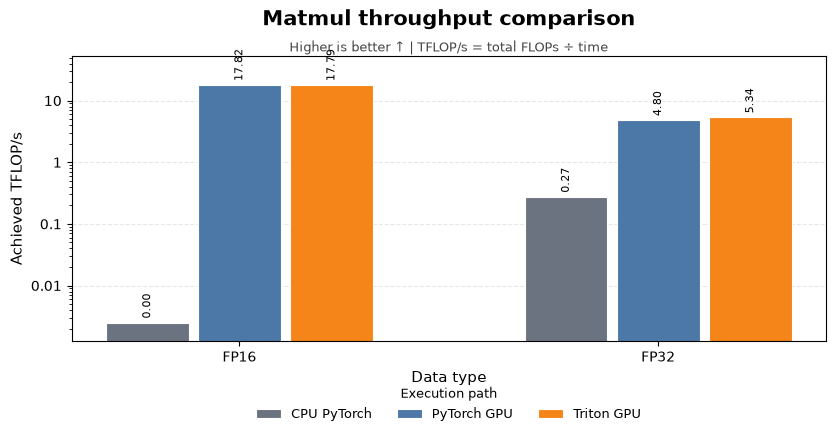

In [15]:
flops_results, fig, ax = plot_matmul_tflops(benchmark_results)
display(flops_results.round({"latency_ms": 4, "tflops": 4}))
plt.show()


this is why GPU scales FLOPS greater than CPU, and this is also one of the reason frontier models start seeking compute scaling first than training model because we already found simply scaling can improve your intelligence 

the I tried to write optimized kernels for this task but it since its one pass matrix multiplixation or Idont know I cant beat the pytorch baselin using triton.

May be we see difference if we doing single forwward pass which go through mutliple layers, well next we try to optimize the 
kernels next time until then bye!

thanks for reading until here!


## Conclusions

thats it thats the end of the blog, you shouldve known by now that how GPU makes the intelligence faster, since the day they found scaling can get you to AGI, jensen start deploying 100s of GB in single chips and start printing money 


the benchmark war you see between frontier today is just scaling, anthropic just dont want others get that scaling and beat their models

I dont think comparing frontier and open weights make sense here because open weights simply doesn't has the power where frontier leads 
